# WWWMD 2: Skill vs Luck in Fantasy Sports (Starter)

In [1]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

In [3]:
import os
cwd = os.getcwd()

## WWWMD 2

In [5]:
wwwmd_2 = pd.read_csv(f'{cwd}/fantasy_wins.csv')
wwwmd_2.head()

,games,wr_1,wr_2
0,185,0.740541,0.664865
1,179,0.586592,0.620112
2,127,0.259843,0.299213
3,2,1.000000,0.500000
4,195,0.517949,0.492308


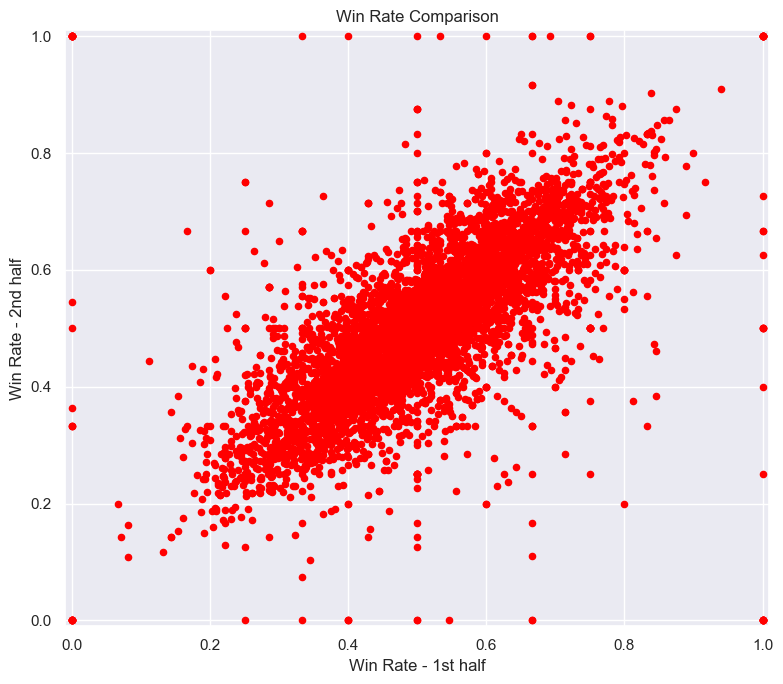

In [6]:
plt.figure(figsize = (8, 7))
plt.scatter(wwwmd_2['wr_1'], wwwmd_2['wr_2'], color = 'red',s = 20)
plt.xlim(-0.01, 1.01)
plt.ylim(-0.01, 1.01)
plt.xlabel('Win Rate - 1st half')
plt.ylabel('Win Rate - 2nd half')
plt.title('Win Rate Comparison')
plt.tight_layout()
plt.show()

# EXPLORING

## section 1: look at W1 by section

In [7]:
bins = np.linspace(0, 1, 11)
labels = [f'{bins[i]:.1f}–{bins[i + 1]:.1f}' for i in range(10)]

wwwmd_2['wr_1_subset'] = pd.cut(
    wwwmd_2['wr_1'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

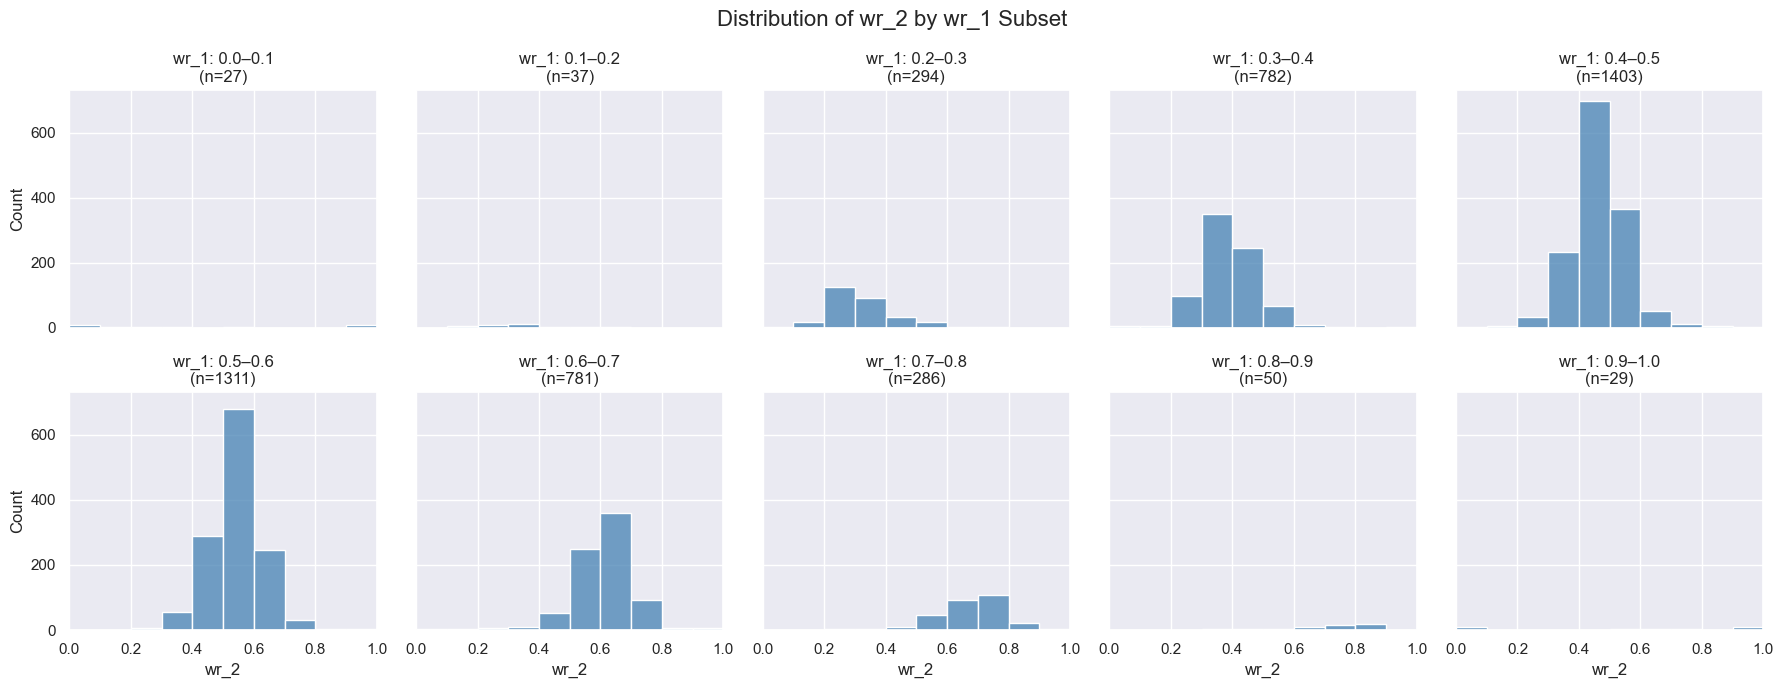

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True, sharey=True)
axes = axes.ravel()

for ax, label in zip(axes, labels):
    subset = wwwmd_2[wwwmd_2['wr_1_subset'] == label]
    
    sns.histplot(
        data=subset,
        x='wr_2',
        bins=np.linspace(0, 1, 11),
        ax=ax,
        color='steelblue',
        edgecolor='white'
    )
    
    ax.set_title(f'wr_1: {label}\n(n={len(subset)})')
    ax.set_xlim(0, 1)
    ax.set_xlabel('wr_2')
    ax.set_ylabel('Count')

fig.suptitle('Distribution of wr_2 by wr_1 Subset', fontsize=16)
plt.tight_layout()
plt.show()

## section 2 - check game counts

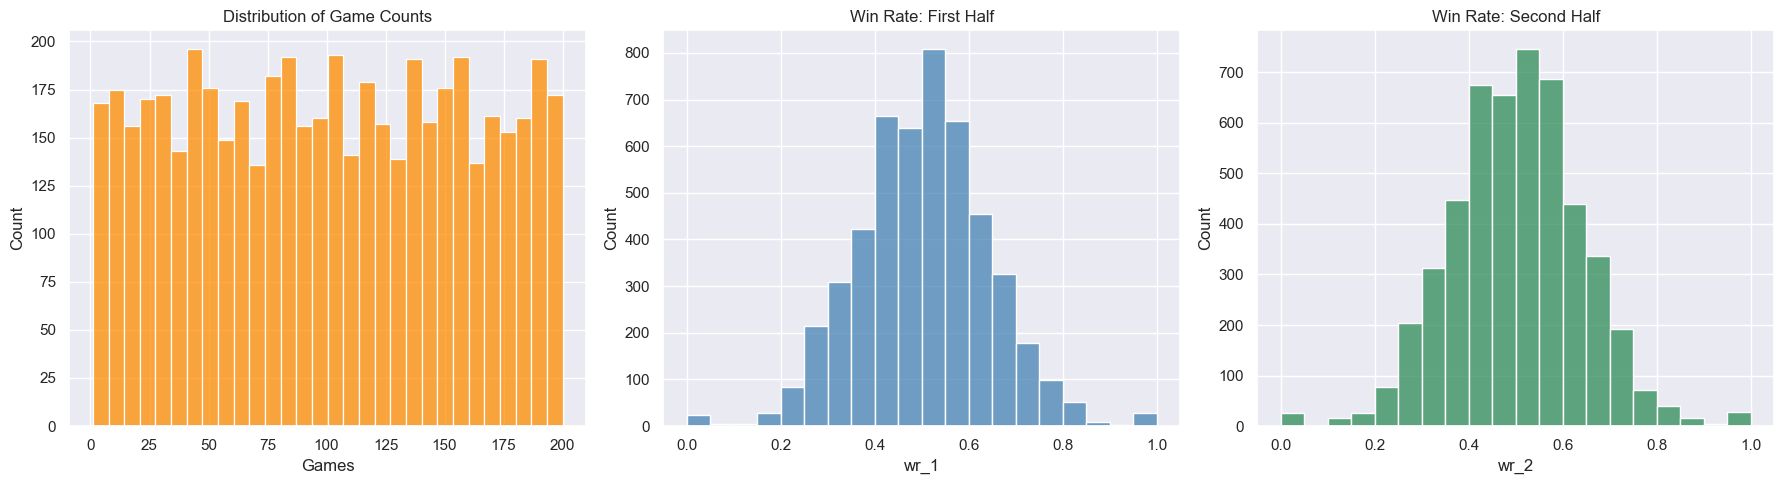

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=wwwmd_2, x='games', bins=30, ax=axes[0], color='darkorange')
axes[0].set_title('Distribution of Game Counts')
axes[0].set_xlabel('Games')
axes[0].set_ylabel('Count')

sns.histplot(data=wwwmd_2, x='wr_1', bins=20, ax=axes[1], color='steelblue')
axes[1].set_title('Win Rate: First Half')
axes[1].set_xlabel('wr_1')

sns.histplot(data=wwwmd_2, x='wr_2', bins=20, ax=axes[2], color='seagreen')
axes[2].set_title('Win Rate: Second Half')
axes[2].set_xlabel('wr_2')

plt.tight_layout()
plt.show()

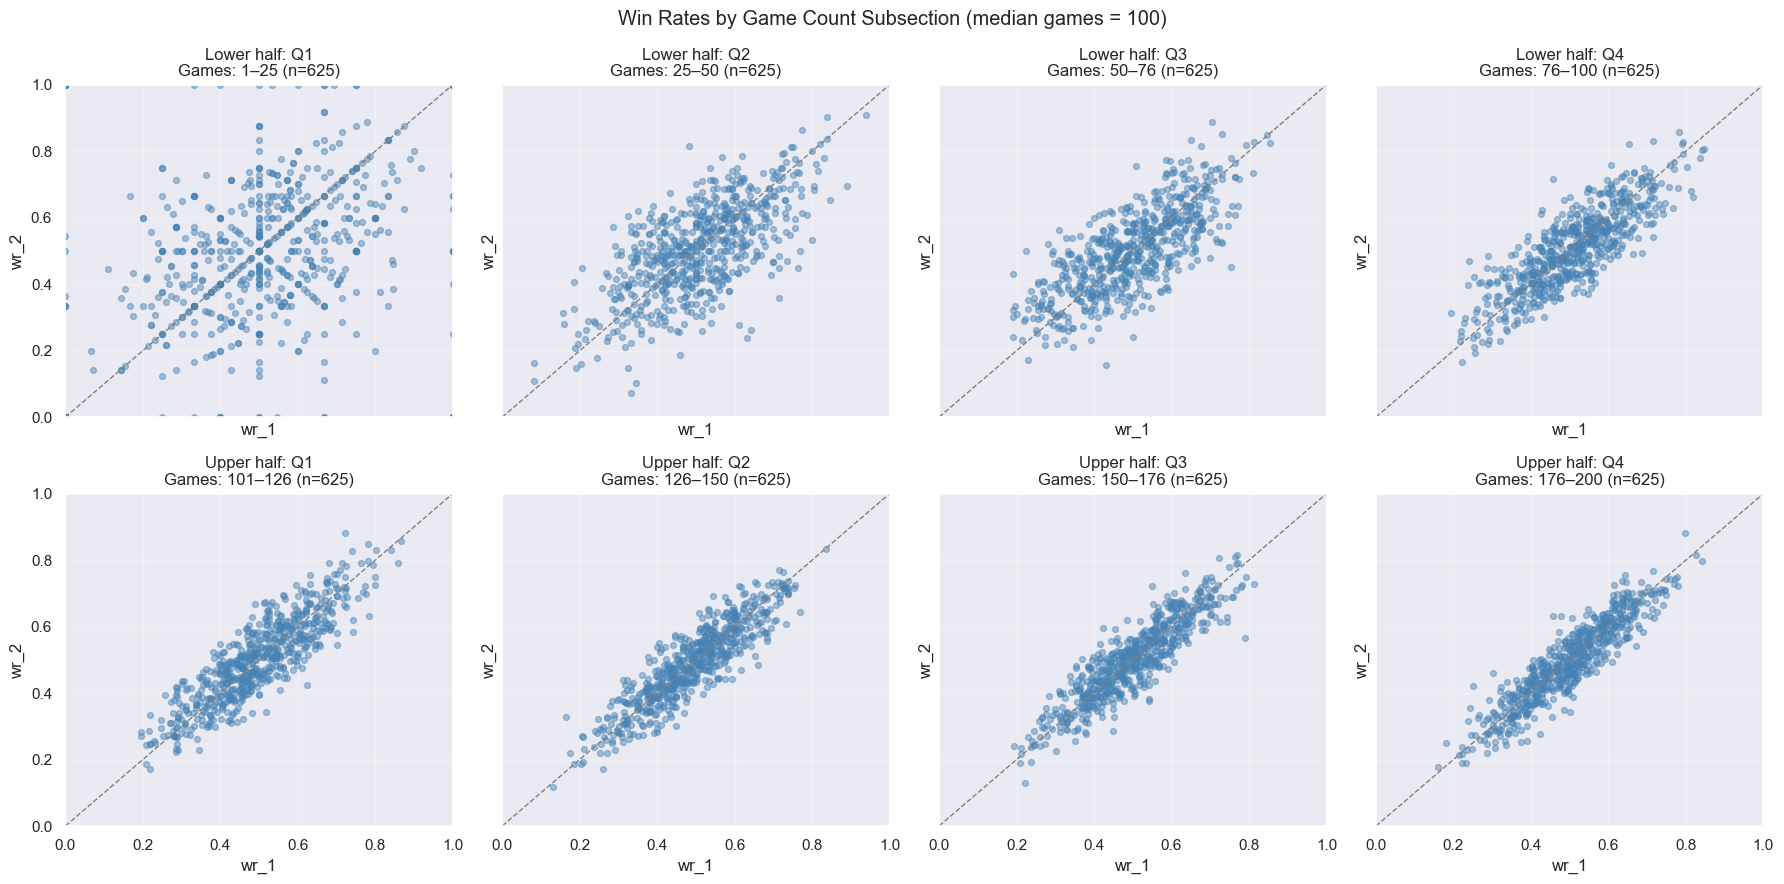

In [16]:
# Plot wr_1 against wr_2 for each game-count subsection,
# including the game-count range in each subplot title.
fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharex=True, sharey=True)
axes = axes.ravel()

subsections = [
    (side, subsection)
    for side in ['Lower half', 'Upper half']
    for subsection in ['Q1', 'Q2', 'Q3', 'Q4']
]

for ax, (side, subsection) in zip(axes, subsections):
    subset = wwwmd_2[
        (wwwmd_2['games_side'] == side) &
        (wwwmd_2['games_subsection'] == subsection)
    ]

    games_min = subset['games'].min()
    games_max = subset['games'].max()

    ax.scatter(
        subset['wr_1'],
        subset['wr_2'],
        alpha=0.45,
        s=18,
        color='steelblue'
    )
    ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)

    ax.set_title(
        f'{side}: {subsection}\n'
        f'Games: {games_min}–{games_max} (n={len(subset)})'
    )
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('wr_1')
    ax.set_ylabel('wr_2')
    ax.grid(alpha=0.25)

fig.suptitle(
    f'Win Rates by Game Count Subsection '
    f'(median games = {games_median:.0f})'
)
plt.tight_layout()
plt.show()

In [18]:
# Correlation between first- and second-half win rates for each game-count subset
subset_correlations = (
    wwwmd_2.groupby(['games_side', 'games_subsection'], observed=True)
    .apply(lambda group: group['wr_1'].corr(group['wr_2']))
    .rename('wr_1_wr_2_correlation')
    .reset_index()
)

subset_counts = (
    wwwmd_2.groupby(['games_side', 'games_subsection'], observed=True)
    .agg(
        n=('wr_1', 'size'),
        games_min=('games', 'min'),
        games_max=('games', 'max')
    )
    .reset_index()
)

subset_correlations = (
    subset_counts
    .merge(subset_correlations, on=['games_side', 'games_subsection'])
    .sort_values(['games_side', 'games_subsection'])
)

subset_correlations

/var/folders/k7/wvbn748s3fjdzzpylvdddhg80000gn/T/ipykernel_4171/1102560933.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  wwwmd_2.groupby(['games_side', 'games_subsection'], observed=True)


,games_side,games_subsection,n,games_min,games_max,wr_1_wr_2_correlation
0,Lower half,Q1,625,1,25,0.265100
1,Lower half,Q2,625,25,50,0.667466
2,Lower half,Q3,625,50,76,0.747149
3,Lower half,Q4,625,76,100,0.828221
4,Upper half,Q1,625,101,126,0.868551
5,Upper half,Q2,625,126,150,0.895546
6,Upper half,Q3,625,150,176,0.897516
7,Upper half,Q4,625,176,200,0.917771
